In [0]:
BRONZE = "churn_project.bronze"

import pyspark.sql.functions as F
import pandas as pd
import matplotlib.pyplot as plt

# Load Bronze tables we'll need for this notebook
df_train      = spark.table(f"{BRONZE}.train_v2")
df_members    = spark.table(f"{BRONZE}.members")
df_txn_train  = spark.table(f"{BRONZE}.transactions_train")
df_logs_train = spark.table(f"{BRONZE}.user_logs_train")

In [0]:
# Baseline renewal rate.
churn_summary = (
    df_train
    .groupBy("is_churn")
    .agg(F.count("*").alias("user_count"))
    .orderBy("is_churn")
)

churn_summary_pd = churn_summary.toPandas()
print("Churn distribution (train_v2):")
print(churn_summary_pd.to_string(index=False))

total_users  = churn_summary_pd["user_count"].sum()
churned      = churn_summary_pd.loc[churn_summary_pd["is_churn"] == 1, "user_count"].values[0]
churn_rate   = churned / total_users
renewal_rate = 1 - churn_rate

print(f"\nTotal labeled users : {total_users:,}")
print(f"Churned (is_churn=1): {churned:,}")
print(f"Churn rate           : {churn_rate:.4f}  ({churn_rate*100:.2f}%)")
print(f"BASELINE RENEWAL RATE: {renewal_rate:.4f}  ({renewal_rate*100:.2f}%)")

Churn distribution (train_v2):
 is_churn  user_count
        0      883630
        1       87330

Total labeled users : 970,960
Churned (is_churn=1): 87,330
Churn rate           : 0.0899  (8.99%)
BASELINE RENEWAL RATE: 0.9101  (91.01%)


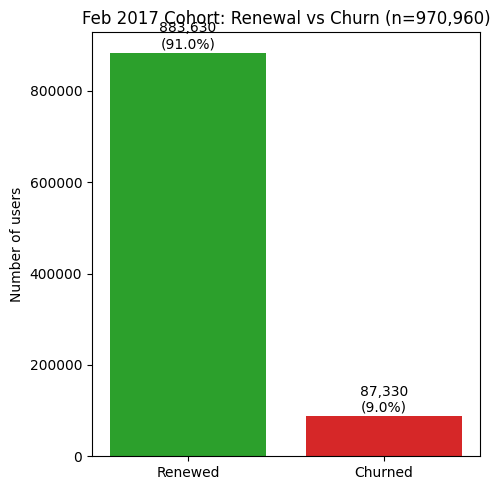

In [0]:
fig, ax = plt.subplots(figsize=(5, 5))

labels = ["Renewed", "Churned"]
values = [
    churn_summary_pd.loc[churn_summary_pd["is_churn"] == 0, "user_count"].values[0],
    churn_summary_pd.loc[churn_summary_pd["is_churn"] == 1, "user_count"].values[0],
]
colors = ["#2ca02c", "#d62728"]

ax.bar(labels, values, color=colors)
ax.set_ylabel("Number of users")
ax.set_title(f"Feb 2017 Cohort: Renewal vs Churn (n={total_users:,})")

for i, v in enumerate(values):
    pct = v / total_users * 100
    ax.text(i, v + total_users*0.01, f"{v:,}\n({pct:.1f}%)", ha="center")

plt.tight_layout()
plt.show()

**Observation:** Of the 970,960 users whose subscriptions expired in February 2017,
91.01% renewed within 30 days and 8.99% churned. This is a high baseline renewal
rate, consistent with a subscription service where auto-renew is the default for
many users. This 91.01% figure is the empirical baseline renewal rate used
throughout the rest of this project- in power analysis (Step 5) and outcome
simulation (Step 6).

**Note for Experiment Design:** because the baseline sits close to 100%, detecting a small
absolute lift (e.g. 2pp) will require careful attention to sample size- the
relative lift at this baseline is much smaller than it would be at, say a 30-60%
baseline.

In [0]:
#Check distribution of membership_expire_date (should be Feb 2017 concentrated)
# We join train_v2 (our train set) with transactions_train to check this

expiry_check= (
    df_txn_train.join(df_train, on="msno", how="inner")
    .groupBy(F.date_format("membership_expire_date", "yyyy-MM").alias("expiry_month"))
    .agg(F.countDistinct("msno").alias("user_count"))
    .orderBy("Expiry_month")
)

expiry_check_pd = expiry_check.toPandas()
print("Membership expiry month distribution (train_v2 users, all their transactions):")
print(expiry_check_pd.to_string(index=False))

Membership expiry month distribution (train_v2 users, all their transactions):
expiry_month  user_count
        None         200
     2016-12          63
     2017-01       18406
     2017-02      795559
     2017-03      927467


In [0]:
from pyspark.sql.window import Window

# For each user, get their most recent transaction (by transaction_date)
window_spec = Window.partitionBy("msno").orderBy(F.col("transaction_date").desc())

latest_txn_per_user = (
    df_txn_train
    .withColumn("rn", F.row_number().over(window_spec))
    .filter(F.col("rn") == 1)
    .select("msno", "transaction_date", "membership_expire_date")
)

latest_expiry_check = (
    latest_txn_per_user
    .join(df_train, "msno", "inner")
    .groupBy(F.date_format("membership_expire_date", "yyyy-MM").alias("latest_expiry_month"))
    .agg(F.countDistinct("msno").alias("user_count"))
    .orderBy("latest_expiry_month")
)

latest_expiry_pd = latest_expiry_check.toPandas()
print("Latest expiry month distribution (one row per labeled user, most recent transaction):")
print(latest_expiry_pd.to_string(index=False))

total_with_txn = latest_expiry_pd["user_count"].sum()
print(f"\nTotal labeled users with at least one transaction: {total_with_txn:,}")
print(f"(Recall: {total_users - total_with_txn:,} labeled users have no transaction record in this window)")

Latest expiry month distribution (one row per labeled user, most recent transaction):
latest_expiry_month  user_count
               None           8
            2017-01         157
            2017-02       17460
            2017-03      919361

Total labeled users with at least one transaction: 936,986
(Recall: 33,974 labeled users have no transaction record in this window)


In [0]:
# Hypothesis check: for users with latest_expiry in March, do they also have
# an earlier transaction with expiry in February? This would confirm the
# "renewed and got pushed to March" theory.

# Get ALL transactions for labeled users, ranked by transaction date
window_spec_asc = Window.partitionBy("msno").orderBy(F.col("transaction_date").asc())

all_txn_ranked = (
    df_txn_train
    .join(df_train.select("msno"), "msno", "inner")
    .withColumn("txn_rank", F.row_number().over(window_spec_asc))
)

# Does each user have at least one transaction with expiry in Feb 2017?
users_with_feb_expiry = (
    all_txn_ranked
    .filter(F.date_format("membership_expire_date", "yyyy-MM") == "2017-02")
    .select("msno")
    .distinct()
)

print(f"Labeled users with at least one transaction expiring in Feb 2017: {users_with_feb_expiry.count():,}")
print(f"(Compare to total labeled users with any transaction: 936,986)")

# Sample a user whose latest expiry is March but who also has a Feb expiry txn
sample_user = (
    latest_txn_per_user
    .filter(F.date_format("membership_expire_date", "yyyy-MM") == "2017-03")
    .join(users_with_feb_expiry, "msno", "inner")
    .limit(1)
    .select("msno")
)

sample_msno = sample_user.collect()[0]["msno"]
print(f"\nFull transaction history for sample user with March latest-expiry: {sample_msno}")
df_txn_train.filter(F.col("msno") == sample_msno).orderBy("transaction_date").show(truncate=False)

Labeled users with at least one transaction expiring in Feb 2017: 795,559
(Compare to total labeled users with any transaction: 936,986)

Full transaction history for sample user with March latest-expiry: ib87AbtWdYraJUwiWQe6kRVJ/xg8JME+aUVafi3GJMM=
+--------------------------------------------+-----------------+-----------------+---------------+------------------+-------------+----------------+----------------------+---------+
|msno                                        |payment_method_id|payment_plan_days|plan_list_price|actual_amount_paid|is_auto_renew|transaction_date|membership_expire_date|is_cancel|
+--------------------------------------------+-----------------+-----------------+---------------+------------------+-------------+----------------+----------------------+---------+
|ib87AbtWdYraJUwiWQe6kRVJ/xg8JME+aUVafi3GJMM=|41               |30               |149            |149               |1            |2017-01-19      |2017-02-20            |0        |
|ib87AbtWdYraJUwiWQe6k

In [0]:
# Who are the 141,427 users with transactions but no Feb-2017 expiry?
users_without_feb_expiry = (
    df_train
    .join(latest_txn_per_user.select("msno"), "msno", "inner")   # has at least one txn
    .join(users_with_feb_expiry, "msno", "left_anti")             # but NOT in the Feb-expiry set
)

print(f"Users with transactions but no Feb-2017 expiry: {users_without_feb_expiry.count():,}")

print("\nWhat does their latest expiry month distribution look like?")
(
    users_without_feb_expiry
    .join(latest_txn_per_user, "msno", "inner")
    .groupBy(F.date_format("membership_expire_date", "yyyy-MM").alias("latest_expiry_month"))
    .agg(F.countDistinct("msno").alias("user_count"))
    .orderBy("latest_expiry_month")
    .show(20)
)

print("\nChurn rate for this group vs overall:")
(
    users_without_feb_expiry
    .groupBy("is_churn")
    .agg(F.count("*").alias("user_count"))
    .orderBy("is_churn")
    .show()
)

print("\nSample user from this group, full transaction history:")
sample2 = users_without_feb_expiry.limit(1).collect()[0]["msno"]
df_txn_train.filter(F.col("msno") == sample2).orderBy("transaction_date").show(truncate=False)

Users with transactions but no Feb-2017 expiry: 141,427

What does their latest expiry month distribution look like?
+-------------------+----------+
|latest_expiry_month|user_count|
+-------------------+----------+
|               NULL|         7|
|            2017-01|       100|
|            2017-03|    141320|
+-------------------+----------+


Churn rate for this group vs overall:
+--------+----------+
|is_churn|user_count|
+--------+----------+
|       0|    119425|
|       1|     22002|
+--------+----------+


Sample user from this group, full transaction history:
+--------------------------------------------+-----------------+-----------------+---------------+------------------+-------------+----------------+----------------------+---------+
|msno                                        |payment_method_id|payment_plan_days|plan_list_price|actual_amount_paid|is_auto_renew|transaction_date|membership_expire_date|is_cancel|
+--------------------------------------------+-------------

In [0]:
# Confirm: churn rate comparison
total_with_feb_expiry = 795559
churned_with_feb = 795559 - df_train.join(users_with_feb_expiry, "msno", "inner").filter("is_churn=0").count()

print("Churn rate comparison:")
print(f"  Users WITH Feb-expiry checkpoint visible : churn rate = ?")
print(f"  Users WITHOUT Feb-expiry checkpoint       : churn rate = {22002/141427*100:.2f}%  (n={141427:,})")
print(f"  Overall                                   : churn rate = 8.99%  (n=970,960)")

(
    df_train
    .join(users_with_feb_expiry, "msno", "inner")
    .groupBy("is_churn")
    .agg(F.count("*").alias("user_count"))
    .orderBy("is_churn")
    .show()
)

Churn rate comparison:
  Users WITH Feb-expiry checkpoint visible : churn rate = ?
  Users WITHOUT Feb-expiry checkpoint       : churn rate = 15.56%  (n=141,427)
  Overall                                   : churn rate = 8.99%  (n=970,960)
+--------+----------+
|is_churn|user_count|
+--------+----------+
|       0|    758867|
|       1|     36692|
+--------+----------+



## Data Quality Finding — "Latest expiry" is not a safe reference point (label leakage risk)

Initial assumption: each labeled user's most recent transaction would show an
expiry date in February 2017, matching Kaggle's cohort definition. Investigation
showed only 17,460 of 936,986 transacting users (1.9%) have their *latest* expiry
in February- the vast majority (919,361 users, 98.1%) show March.

**Root cause:** for users who renewed, their renewal transaction creates a new,
later expiry date. Using "latest transaction" as the reference point would mean
computing features partly from data generated *after* the renewal decision we're
trying to predict- a form of label leakage.

**Fix:** each user's reference point is their transaction whose
`membership_expire_date` falls in February 2017 (the actual Kaggle cohort
checkpoint)-  not their latest transaction.

**Secondary finding:** 795,559 of 936,986 transacting users (84.9%) have a
visible February-expiry transaction within our 60-day trim window. The
remaining 141,427 (15.1%) do not- most likely because their prior subscription
cycle began before our Jan 1 cutoff (e.g. longer-duration plans, infrequent
renewers). This group shows a substantially higher churn rate (15.56% vs 4.61%
for users with a visible checkpoint)- a 3.4x difference.

**Decision:** rather than re-trimming with a wider window (which would mostly
just add volume for marginal coverage gain, per our earlier window-comparison
analysis), we encode this as a feature: `has_feb_checkpoint` (1/0). For users
without a visible checkpoint, we use their earliest available transaction in
the window as a fallback reference point. The flag itself is likely to be
predictive, given the churn rate gap observed.



## Verifying cohort definitions empirically

Kaggle's description of `train_v2.csv` ("contains the churn data for March, 2017")
is ambiguous- it could mean users *expire* in March, or that their renewal
outcome is *resolved/observed* by March. We tested this directly rather than
guessing:

- `train.csv` (992,931 users): 90.8% have a transaction expiring in **January 2017**
- `train_v2.csv` (970,960 users): 84.9% have a transaction expiring in **February 2017**

This confirms `train.csv` = Jan-expiry cohort, `train_v2.csv` = Feb-expiry cohort.
The "March" in the description refers to when the 30-day renewal window closes
and the churn outcome becomes observable — not the expiry month. We proceed
using `train_v2.csv` as our sole label source, as originally planned.

In [0]:
#Auto-Renew Vs Manual Renewal Share

# Using the FULL set of transacting users for general EDA.

# A user can have multiple transactions with different is_auto_renew values
# over time (e.g. they could switch). We look at this per-transaction first,
# then per-user (most recent stance) for a cleaner picture.

print("Auto-renew distribution — per TRANSACTION:")
(
    df_txn_train
    .groupBy("is_auto_renew")
    .agg(F.count("*").alias("txn_count"))
    .orderBy("is_auto_renew")
    .show()
)

print("Auto-renew distribution — per USER (most recent transaction's setting):")
window_latest = Window.partitionBy("msno").orderBy(F.col("transaction_date").desc())

user_latest_auto_renew = (
    df_txn_train
    .withColumn("rn", F.row_number().over(window_latest))
    .filter(F.col("rn") == 1)
    .select("msno", "is_auto_renew")
)

auto_renew_summary = (
    user_latest_auto_renew
    .groupBy("is_auto_renew")
    .agg(F.count("*").alias("user_count"))
    .orderBy("is_auto_renew")
)

auto_renew_pd = auto_renew_summary.toPandas()
print(auto_renew_pd.to_string(index=False))

total_with_setting = auto_renew_pd["user_count"].sum()
for _, row in auto_renew_pd.iterrows():
    pct = row["user_count"] / total_with_setting * 100
    label = "Auto-renew ON" if row["is_auto_renew"] == 1 else "Auto-renew OFF (manual)"
    print(f"  {label}: {row['user_count']:,} ({pct:.1f}%)")

Auto-renew distribution — per TRANSACTION:
+-------------+---------+
|is_auto_renew|txn_count|
+-------------+---------+
|            0|   148334|
|            1|  1623515|
+-------------+---------+

Auto-renew distribution — per USER (most recent transaction's setting):
 is_auto_renew  user_count
             0       89626
             1      847360
  Auto-renew OFF (manual): 89,626 (9.6%)
  Auto-renew ON: 847,360 (90.4%)


In [0]:
# Does auto-renew status correlate with churn?

# Join the per-user latest auto-renew setting to churn labels
auto_renew_churn = (
    user_latest_auto_renew
    .join(df_train, "msno", "inner")
    .groupBy("is_auto_renew", "is_churn")
    .agg(F.count("*").alias("user_count"))
    .orderBy("is_auto_renew", "is_churn")
)

auto_renew_churn_pd = auto_renew_churn.toPandas()
print(auto_renew_churn_pd.to_string(index=False))

print("\nChurn rate by auto-renew status:")
for ar_val in [0, 1]:
    subset = auto_renew_churn_pd[auto_renew_churn_pd["is_auto_renew"] == ar_val]
    total = subset["user_count"].sum()
    churned = subset[subset["is_churn"] == 1]["user_count"].sum()
    label = "Auto-renew ON" if ar_val == 1 else "Auto-renew OFF"
    print(f"  {label}: {churned:,} / {total:,} = {churned/total*100:.2f}% churn rate")

 is_auto_renew  is_churn  user_count
             0         0       63206
             0         1       26420
             1         0      815086
             1         1       32274

Churn rate by auto-renew status:
  Auto-renew OFF: 26,420 / 89,626 = 29.48% churn rate
  Auto-renew ON: 32,274 / 847,360 = 3.81% churn rate


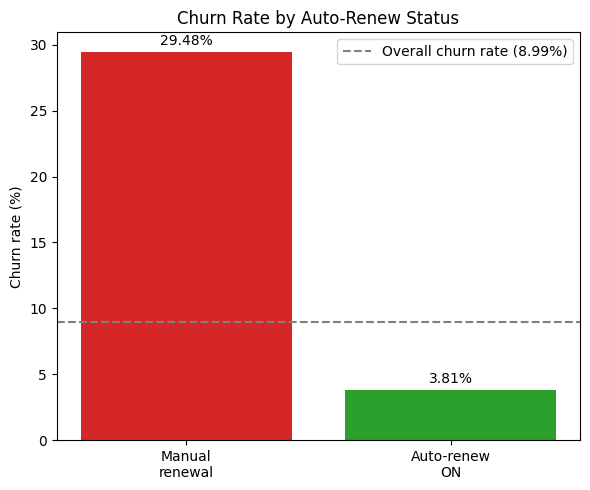

In [0]:
fig, ax = plt.subplots(figsize=(6, 5))

churn_rates = []
labels = []
for ar_val in [0, 1]:
    subset = auto_renew_churn_pd[auto_renew_churn_pd["is_auto_renew"] == ar_val]
    total = subset["user_count"].sum()
    churned = subset[subset["is_churn"] == 1]["user_count"].sum()
    churn_rates.append(churned / total * 100)
    labels.append("Manual\nrenewal" if ar_val == 0 else "Auto-renew\nON")

ax.bar(labels, churn_rates, color=["#d62728", "#2ca02c"])
ax.set_ylabel("Churn rate (%)")
ax.set_title("Churn Rate by Auto-Renew Status")
ax.axhline(y=8.99, color="gray", linestyle="--", label="Overall churn rate (8.99%)")
ax.legend()

for i, v in enumerate(churn_rates):
    ax.text(i, v + 0.5, f"{v:.2f}%", ha="center")

plt.tight_layout()
plt.show()

**Observation:** Auto-renew status is one of the strongest churn signals in the
data. Users with auto-renew OFF (manual renewal, 9.6% of the cohort) churn at
29.48%-  nearly 8x the rate of auto-renew ON users (3.81% churn, 90.4% of the
cohort). This gap (25.7 percentage points) far exceeds the overall churn rate
of 8.99%, suggesting auto-renew status will be a high-importance feature in the
churn model and a natural lens for segment targeting in the experiment design.

In [0]:
# Plan length distribution

print("payment_plan_days distribution — per transaction:")
(
    df_txn_train
    .groupBy("payment_plan_days")
    .agg(F.count("*").alias("txn_count"))
    .orderBy(F.col("txn_count").desc())
    .show(15)
)

print("\npayment_plan_days — per user, most recent transaction:")
window_latest_plan = Window.partitionBy("msno").orderBy(F.col("transaction_date").desc())

user_latest_plan = (
    df_txn_train
    .withColumn("rn", F.row_number().over(window_latest_plan))
    .filter(F.col("rn") == 1)
    .select("msno", "payment_plan_days")
)

plan_dist = (
    user_latest_plan
    .groupBy("payment_plan_days")
    .agg(F.count("*").alias("user_count"))
    .orderBy(F.col("user_count").desc())
)

plan_dist_pd = plan_dist.toPandas()
print(plan_dist_pd.to_string(index=False))

total_plan_users = plan_dist_pd["user_count"].sum()
top_plan_pct = plan_dist_pd.iloc[0]["user_count"] / total_plan_users * 100
print(f"\nMost common plan ({plan_dist_pd.iloc[0]['payment_plan_days']} days) covers {top_plan_pct:.1f}% of users")

payment_plan_days distribution — per transaction:
+-----------------+---------+
|payment_plan_days|txn_count|
+-----------------+---------+
|               30|  1768932|
|               45|     1082|
|                7|      746|
|               60|      736|
|                1|      144|
|              240|       83|
|              120|       49|
|               10|       29|
|               70|       13|
|              195|       11|
|              395|        9|
|              410|        6|
|               80|        4|
|              180|        3|
|               21|        2|
+-----------------+---------+


payment_plan_days — per user, most recent transaction:
 payment_plan_days  user_count
                30      935081
                45        1080
                60         475
                 7         147
                 1          65
               240          62
               120          23
                10          16
                70          11
             

In [0]:
# Does plan length correlate with churn behavior?

# Bucket plan lengths into sensible groups for readability, then check churn rate
plan_churn = (
    user_latest_plan
    .join(df_train, "msno", "inner")
    .withColumn(
        "plan_bucket",
        F.when(F.col("payment_plan_days") <= 7, "≤7 days")
         .when(F.col("payment_plan_days") <= 31, "8-31 days (monthly)")
         .when(F.col("payment_plan_days") <= 99, "32-99 days (quarterly-ish)")
         .when(F.col("payment_plan_days") <= 200, "100-200 days")
         .otherwise("200+ days (annual+)")
    )
    .groupBy("plan_bucket")
    .agg(
        F.count("*").alias("total_users"),
        F.sum("is_churn").alias("churned_users")
    )
    .withColumn("churn_rate_pct", F.round(F.col("churned_users") / F.col("total_users") * 100, 2))
    .orderBy(F.col("total_users").desc())
)

plan_churn_pd = plan_churn.toPandas()
print(plan_churn_pd.to_string(index=False))

               plan_bucket  total_users  churned_users  churn_rate_pct
       8-31 days (monthly)       935097          57470            6.15
32-99 days (quarterly-ish)         1570            970           61.78
                   ≤7 days          212            152           71.70
       200+ days (annual+)           73             73          100.00
              100-200 days           34             29           85.29


In [0]:
# Investigate the extreme buckets

print("Sample of users on 200+ day plans (100% churn) — full transaction history for a few:")
long_plan_users = (
    user_latest_plan
    .filter(F.col("payment_plan_days") >= 200)
    .select("msno")
    .limit(3)
)

for row in long_plan_users.collect():
    print(f"\n--- User: {row['msno']} ---")
    df_txn_train.filter(F.col("msno") == row["msno"]).orderBy("transaction_date").show(truncate=False)

print("\nSample of users on ≤7 day plans (71.7% churn):")
short_plan_users = (
    user_latest_plan
    .filter(F.col("payment_plan_days") <= 7)
    .select("msno")
    .limit(3)
)

for row in short_plan_users.collect():
    print(f"\n--- User: {row['msno']} ---")
    df_txn_train.filter(F.col("msno") == row["msno"]).orderBy("transaction_date").show(truncate=False)

# Also check: is_cancel rate for these extreme buckets vs the 30-day norm
print("\nis_cancel rate by plan bucket (latest transaction):")
(
    user_latest_plan
    .withColumn(
        "plan_bucket",
        F.when(F.col("payment_plan_days") <= 7, "≤7 days")
         .when(F.col("payment_plan_days") <= 31, "8-31 days")
         .when(F.col("payment_plan_days") <= 99, "32-99 days")
         .when(F.col("payment_plan_days") <= 200, "100-200 days")
         .otherwise("200+ days")
    )
    .join(df_txn_train.select("msno", "is_cancel"), "msno", "inner")
    .groupBy("plan_bucket")
    .agg(F.avg("is_cancel").alias("avg_cancel_rate"))
    .show()
)

Sample of users on 200+ day plans (100% churn) — full transaction history for a few:

--- User: 7+nZMmz+wGQ3OMn2Nu7pp0a5lAR4dxwQK0x6PRwjGYw= ---
+--------------------------------------------+-----------------+-----------------+---------------+------------------+-------------+----------------+----------------------+---------+
|msno                                        |payment_method_id|payment_plan_days|plan_list_price|actual_amount_paid|is_auto_renew|transaction_date|membership_expire_date|is_cancel|
+--------------------------------------------+-----------------+-----------------+---------------+------------------+-------------+----------------+----------------------+---------+
|7+nZMmz+wGQ3OMn2Nu7pp0a5lAR4dxwQK0x6PRwjGYw=|17               |240              |0              |0                 |0            |2017-02-28      |2017-03-03            |0        |
+--------------------------------------------+-----------------+-----------------+---------------+------------------+----------

In [0]:
# Test the hypothesis: do all "unusual" plan lengths coincide with $0 payments?

print("Cross-tab: plan_bucket vs whether actual_amount_paid = 0")
(
    user_latest_plan
    .join(df_txn_train.select("msno", "actual_amount_paid"), "msno", "inner")
    .withColumn(
        "plan_bucket",
        F.when(F.col("payment_plan_days") <= 7, "≤7 days")
         .when(F.col("payment_plan_days") <= 31, "8-31 days")
         .when(F.col("payment_plan_days") <= 99, "32-99 days")
         .when(F.col("payment_plan_days") <= 200, "100-200 days")
         .otherwise("200+ days")
    )
    .withColumn("is_free", F.when(F.col("actual_amount_paid") == 0, "Free ($0)").otherwise("Paid"))
    .groupBy("plan_bucket", "is_free")
    .agg(F.count("*").alias("user_count"))
    .orderBy("plan_bucket", "is_free")
    .show()
)

Cross-tab: plan_bucket vs whether actual_amount_paid = 0
+------------+---------+----------+
| plan_bucket|  is_free|user_count|
+------------+---------+----------+
|100-200 days|Free ($0)|        34|
|100-200 days|     Paid|        12|
|   200+ days|Free ($0)|        73|
|   200+ days|     Paid|        16|
|  32-99 days|Free ($0)|       267|
|  32-99 days|     Paid|      1533|
|   8-31 days|Free ($0)|      5519|
|   8-31 days|     Paid|   1763954|
|     ≤7 days|Free ($0)|       231|
|     ≤7 days|     Paid|       210|
+------------+---------+----------+



**Observation:** 99.8% of users are on the standard 30-day subscription plan.
The small remainder (1,879 users, 0.2%) shows extreme churn rates in the
62-100% range, but investigation of sample transactions shows this population
is contaminated by likely trial/grace-period/cancellation-artifact records-
disproportionately $0 payment transactions where `payment_plan_days` does not
appear to reflect a genuine subscription length (e.g. `payment_plan_days=240`
but `membership_expire_date` only 3-5 days after the transaction). This effect
is strongest in the 100+ day buckets (74-82% are $0 transactions) and weaker in
the 32-99 day bucket (only 15% are $0, suggesting more genuine paid plans there).

**Decision:** plan length is not built as a meaningful churn feature given 99.8%
concentration on a single value. The non-standard tail is too small and too
contaminated with artifacts to extract a clean signal, and is not worth further
investigation given its negligible weight in the overall population.

In [0]:
# is_cancel is a per-TRANSACTION flag. A user can have multiple transactions;
# we check whether the user EVER actively cancelled during our window,
# not just their latest transaction's status.

user_ever_cancelled = (
    df_txn_train
    .groupBy("msno")
    .agg(F.max("is_cancel").alias("ever_cancelled"))  # 1 if any transaction has is_cancel=1
)

cancel_summary = (
    user_ever_cancelled
    .groupBy("ever_cancelled")
    .agg(F.count("*").alias("user_count"))
    .orderBy("ever_cancelled")
)

cancel_pd = cancel_summary.toPandas()
print("Users who ever actively cancelled during the window:")
print(cancel_pd.to_string(index=False))

total_cancel_users = cancel_pd["user_count"].sum()
for _, row in cancel_pd.iterrows():
    pct = row["user_count"] / total_cancel_users * 100
    label = "Cancelled at least once" if row["ever_cancelled"] == 1 else "Never cancelled"
    print(f"  {label}: {row['user_count']:,} ({pct:.1f}%)")

Users who ever actively cancelled during the window:
 ever_cancelled  user_count
              0      907748
              1       29238
  Never cancelled: 907,748 (96.9%)
  Cancelled at least once: 29,238 (3.1%)


In [0]:
# This is the key business question: does an active cancellation (which
# doesn't necessarily mean churn, per Kaggle's definition) actually predict
# churn in practice?

cancel_churn = (
    user_ever_cancelled
    .join(df_train, "msno", "inner")
    .groupBy("ever_cancelled", "is_churn")
    .agg(F.count("*").alias("user_count"))
    .orderBy("ever_cancelled", "is_churn")
)

cancel_churn_pd = cancel_churn.toPandas()
print(cancel_churn_pd.to_string(index=False))

print("\nChurn rate by cancellation history:")
for c_val in [0, 1]:
    subset = cancel_churn_pd[cancel_churn_pd["ever_cancelled"] == c_val]
    total = subset["user_count"].sum()
    churned = subset[subset["is_churn"] == 1]["user_count"].sum()
    label = "Cancelled at least once" if c_val == 1 else "Never cancelled"
    print(f"  {label}: {churned:,} / {total:,} = {churned/total*100:.2f}% churn rate")

 ever_cancelled  is_churn  user_count
              0         0      857011
              0         1       50737
              1         0       21281
              1         1        7957

Churn rate by cancellation history:
  Never cancelled: 50,737 / 907,748 = 5.59% churn rate
  Cancelled at least once: 7,957 / 29,238 = 27.21% churn rate


**Observation:** 3.1% of users actively cancelled at least one subscription
during the Jan-Feb window. Although documentation explicitly notes
that cancellation does not imply churn (a user may cancel to change plans),
in practice cancellers churn at 27.21% vs 5.59% for non-cancellers-  a ~5x
gap. `ever_cancelled` is a strong candidate churn feature alongside auto-renew
status.


In [0]:
# We already found 6,124 zero-payment transactions (0.35%) during ingestion
# exploration. Let's now look at it from a churn-relevance angle: does having
# a promo/discount transaction relate to churn?

user_ever_zero_paid = (
    df_txn_train
    .groupBy("msno")
    .agg(F.max(F.when(F.col("actual_amount_paid") == 0, 1).otherwise(0)).alias("ever_zero_paid"))
)

zero_paid_churn = (
    user_ever_zero_paid
    .join(df_train, "msno", "inner")
    .groupBy("ever_zero_paid", "is_churn")
    .agg(F.count("*").alias("user_count"))
    .orderBy("ever_zero_paid", "is_churn")
)

zero_paid_churn_pd = zero_paid_churn.toPandas()
print(zero_paid_churn_pd.to_string(index=False))

print("\nChurn rate by zero-payment history:")
for z_val in [0, 1]:
    subset = zero_paid_churn_pd[zero_paid_churn_pd["ever_zero_paid"] == z_val]
    total = subset["user_count"].sum()
    churned = subset[subset["is_churn"] == 1]["user_count"].sum()
    label = "Had a $0 transaction" if z_val == 1 else "Never had a $0 transaction"
    print(f"  {label}: {churned:,} / {total:,} = {churned/total*100:.2f}% churn rate")

 ever_zero_paid  is_churn  user_count
              0         0      874986
              0         1       56893
              1         0        3306
              1         1        1801

Churn rate by zero-payment history:
  Never had a $0 transaction: 56,893 / 931,879 = 6.11% churn rate
  Had a $0 transaction: 1,801 / 5,107 = 35.27% churn rate


**Observation:** 

Users with at least one $0 transaction churn at 35.27% vs 6.11% for users who never had one a 6x gap, the strongest subscription
behavior signal found so far. This is consistent with our earlier finding
that $0 transactions are disproportionately tied to trial/grace-period/
cancellation-adjacent records rather than stable paid subscriptions. Combined
with auto-renew status (3.3x gap) and cancellation history (~3.0x gap), we
now have three strong subscription-behavior churn signals. These likely
overlap (e.g. a cancellation event often generates a $0 system transaction),
and disentangling their individual contributions is left to the churn model
in Step 4 rather than hand-analysis here.

In [0]:
# Aggregate user_logs_train to one row per user.
# This becomes the engagement summary we'll compare against churn

user_engagement = (
    df_logs_train
    .groupBy("msno")
    .agg(
        F.count("*").alias("active_days"),
        F.sum("total_secs").alias("total_listening_secs"),
        F.sum(F.col("num_25") + F.col("num_50") + F.col("num_75") + F.col("num_985") + F.col("num_100")).alias("total_streams"),
        F.sum("num_100").alias("total_completed_streams"),
        F.avg("num_unq").alias("avg_unique_songs")
    )
    .withColumn("avg_daily_streams", F.col("total_streams") / F.col("active_days"))
    .withColumn("avg_listening_secs_per_day", F.col("total_listening_secs") / F.col("active_days"))
    .withColumn("completion_rate", F.col("total_completed_streams") / F.col("total_streams"))
)

print(f"Engagement summary built for {user_engagement.count():,} users")
user_engagement.show(5, truncate=False)

Engagement summary built for 781,835 users
+--------------------------------------------+-----------+--------------------+-------------+-----------------------+------------------+------------------+--------------------------+------------------+
|msno                                        |active_days|total_listening_secs|total_streams|total_completed_streams|avg_unique_songs  |avg_daily_streams |avg_listening_secs_per_day|completion_rate   |
+--------------------------------------------+-----------+--------------------+-------------+-----------------------+------------------+------------------+--------------------------+------------------+
|odOsJf9kQXCEU9dJAN7/U9HRry77Z9nF8GwkEW6bUh8=|59         |307184.0690000001   |1370         |1193                   |19.54237288135593 |23.220338983050848|5206.509644067798         |0.8708029197080291|
|n0zpf7S8oGH7HLvIy6sNXYlrBtfTNrKr0YhfvSEEjPc=|41         |254116.88799999998  |1179         |920                    |23.024390243902438|28.7560975609

In [0]:
# Join engagement to churn labels and compare distributions
engagement_churn = user_engagement.join(df_train, "msno", "inner")

print("Engagement metrics by churn status (averages):")
(
    engagement_churn
    .groupBy("is_churn")
    .agg(
        F.count("*").alias("user_count"),
        F.round(F.avg("active_days"), 1).alias("avg_active_days"),
        F.round(F.avg("total_listening_secs") / 3600, 1).alias("avg_total_hours"),
        F.round(F.avg("avg_daily_streams"), 1).alias("avg_daily_streams"),
        F.round(F.avg("completion_rate"), 3).alias("avg_completion_rate"),
        F.round(F.avg("avg_unique_songs"), 1).alias("avg_unique_songs")
    )
    .orderBy("is_churn")
    .show()
)

print(f"\nNote: this only covers the {user_engagement.count():,} users with log activity")
print(f"out of {total_users:,} total labeled users (the rest have no engagement data-  handled separately)")

Engagement metrics by churn status (averages):
+--------+----------+---------------+---------------+-----------------+-------------------+----------------+
|is_churn|user_count|avg_active_days|avg_total_hours|avg_daily_streams|avg_completion_rate|avg_unique_songs|
+--------+----------+---------------+---------------+-----------------+-------------------+----------------+
|       0|    708337|           31.9|           69.7|             33.8|              0.694|            24.8|
|       1|     73498|           31.4|           70.5|             35.8|              0.691|            26.4|
+--------+----------+---------------+---------------+-----------------+-------------------+----------------+


Note: this only covers the 781,835 users with log activity
out of 970,960 total labeled users (the rest have no engagement data-  handled separately)


In [0]:
# Check median (more robust to outliers) and the full distribution shape
print("Engagement metrics by churn status — MEDIANS (more robust to outliers):")
(
    engagement_churn
    .groupBy("is_churn")
    .agg(
        F.expr("percentile_approx(active_days, 0.5)").alias("median_active_days"),
        F.round(F.expr("percentile_approx(total_listening_secs, 0.5)") / 3600, 1).alias("median_total_hours"),
        F.expr("percentile_approx(avg_daily_streams, 0.5)").alias("median_daily_streams"),
        F.round(F.expr("percentile_approx(completion_rate, 0.5)"), 3).alias("median_completion_rate")
    )
    .orderBy("is_churn")
    .show()
)

# Also check: what % of EACH group has very low engagement (e.g. < 5 active days)?
# If churners have a fatter "barely used it" tail, the median might reveal what mean hides.
print("Share of each group with low engagement (active_days < 5):")
(
    engagement_churn
    .withColumn("low_engagement", F.when(F.col("active_days") < 5, 1).otherwise(0))
    .groupBy("is_churn")
    .agg(
        F.count("*").alias("total"),
        F.sum("low_engagement").alias("low_engagement_count")
    )
    .withColumn("low_engagement_pct", F.round(F.col("low_engagement_count") / F.col("total") * 100, 2))
    .show()
)

Engagement metrics by churn status — MEDIANS (more robust to outliers):
+--------+------------------+------------------+--------------------+----------------------+
|is_churn|median_active_days|median_total_hours|median_daily_streams|median_completion_rate|
+--------+------------------+------------------+--------------------+----------------------+
|       0|                33|              42.5|                26.8|                 0.732|
|       1|                32|              43.6|  28.666666666666668|                 0.725|
+--------+------------------+------------------+--------------------+----------------------+

Share of each group with low engagement (active_days < 5):
+--------+------+--------------------+------------------+
|is_churn| total|low_engagement_count|low_engagement_pct|
+--------+------+--------------------+------------------+
|       1| 73498|                5666|              7.71|
|       0|708337|               56718|              8.01|
+--------+------+---

**Observation:** Contrary to the initial hypothesis that engaged listeners
churn less, engagement metrics show almost no relationship with churn among
users with logged activity. Churned and renewed users have nearly identical
median active days (32 vs 33), median listening hours (43.6 vs 42.5), and
median completion rates (0.725 vs 0.732). The share of low-engagement users
(<5 active days) is actually slightly lower among churners (7.71%) than
renewers (8.01%) — ruling out a skewed-tail explanation.

**Interpretation:** engagement measures product usage, while churn is driven
by subscription mechanics (auto-renew status, active cancellation) rather
than satisfaction with the listening experience. A user can listen heavily
right up until they cancel. This reframes the project's expected feature
importance: auto-renew status and cancellation history are likely to dominate
the churn model, with engagement features adding comparatively little signal.
This will be tested directly in feature importance analysis (next step).



## Segmentation strategy: two different jobs, two different inputs

Based on what EDA revealed, we use two distinct segmentation approaches:

**For churn risk (Step 4 model, Step 5 eligibility):** subscription mechanics
dominate- auto-renew status (3.3x churn gap), cancellation history (3.0x gap),
and zero-payment history (~6x gap) are the meaningful signals. Engagement showed
no relationship with churn and is not expected to be a strong feature here.

**For experiment segmentation (Step 7):** engagement and tenure remain useful
lenses even though they don't predict churn. The question there is whether
discount *effectiveness* varies by user type, which is a different effect than
churn *propensity*. A heavy listener and light listener flagged as equally
high-risk by the model might respond very differently to a discount offer.

Tenure buckets are used in both contexts. Engagement buckets (heavy/medium/light)
are defined for experiment segmentation only.

In [0]:
# Tenure = how long a user has been with KKBox, based on earliest transaction
# in our window relative to their reference point. We use the full window's
# earliest transaction per user as a simple proxy here (Step 3 will refine
# this with the checkpoint-anchored logic).

user_tenure = (
    df_txn_train
    .groupBy("msno")
    .agg(
        F.min("transaction_date").alias("first_txn_date"),
        F.max("transaction_date").alias("last_txn_date")
    )
    .withColumn("tenure_days_in_window", F.datediff(F.col("last_txn_date"), F.col("first_txn_date")))
)

print("Tenure (within-window span) distribution:")
user_tenure.selectExpr(
    "min(tenure_days_in_window) as min_tenure",
    "percentile_approx(tenure_days_in_window, 0.25) as p25",
    "percentile_approx(tenure_days_in_window, 0.5) as median",
    "percentile_approx(tenure_days_in_window, 0.75) as p75",
    "max(tenure_days_in_window) as max_tenure"
).show()

print("\nNote: this is tenure WITHIN our 60-day window only")

Tenure (within-window span) distribution:
+----------+---+------+---+----------+
|min_tenure|p25|median|p75|max_tenure|
+----------+---+------+---+----------+
|         0| 28|    31| 31|        58|
+----------+---+------+---+----------+


Note: this is tenure WITHIN our 60-day window only


In [0]:
user_tenure_real = (
    df_members
    .select("msno", "registration_init_time")
    .withColumn("reference_date", F.lit("2017-02-28").cast("date"))
    .withColumn("tenure_days", F.datediff(F.col("reference_date"), F.col("registration_init_time")))
    .withColumn("tenure_months", F.round(F.col("tenure_days") / 30.44, 1))
)

print("True tenure (from registration_init_time) distribution:")
user_tenure_real.selectExpr(
    "min(tenure_days) as min_tenure_days",
    "percentile_approx(tenure_days, 0.25) as p25",
    "percentile_approx(tenure_days, 0.5) as median",
    "percentile_approx(tenure_days, 0.75) as p75",
    "max(tenure_days) as max_tenure_days"
).show()

# How many labeled users have a members record at all?
labeled_with_members = df_train.join(user_tenure_real, "msno", "inner").count()
print(f"\nLabeled users with a members record: {labeled_with_members:,} / {total_users:,}")

True tenure (from registration_init_time) distribution:
+---------------+---+------+----+---------------+
|min_tenure_days|p25|median| p75|max_tenure_days|
+---------------+---+------+----+---------------+
|            -60|270|   508|1044|           4722|
+---------------+---+------+----+---------------+


Labeled users with a members record: 860,967 / 970,960


In [0]:
# How many users have negative tenure (registered after our reference date)?
negative_tenure_count = user_tenure_real.filter(F.col("tenure_days") < 0).count()
total_with_tenure = user_tenure_real.count()

print(f"Users with negative tenure (registered after Feb 28, 2017): {negative_tenure_count:,}")
print(f"Total users with a members record: {total_with_tenure:,}")
print(f"Percentage: {negative_tenure_count/total_with_tenure*100:.3f}%")

print("\nDistribution of negative tenure values (how far in the future?):")
user_tenure_real.filter(F.col("tenure_days") < 0).selectExpr(
    "min(tenure_days) as most_negative",
    "max(tenure_days) as least_negative",
    "avg(tenure_days) as avg_negative"
).show()

print("\nSample of negative-tenure users:")
user_tenure_real.filter(F.col("tenure_days") < 0).show(5, truncate=False)

# Also check: do these users overlap with our labeled (train_v2) population?
negative_tenure_labeled = (
    df_train
    .join(user_tenure_real.filter(F.col("tenure_days") < 0), "msno", "inner")
    .count()
)
print(f"\nOf these, how many are in our labeled train_v2 population: {negative_tenure_labeled:,}")

Users with negative tenure (registered after Feb 28, 2017): 154,166
Total users with a members record: 6,769,473
Percentage: 2.277%

Distribution of negative tenure values (how far in the future?):
+-------------+--------------+------------------+
|most_negative|least_negative|      avg_negative|
+-------------+--------------+------------------+
|          -60|            -1|-25.29091369043758|
+-------------+--------------+------------------+


Sample of negative-tenure users:
+--------------------------------------------+----------------------+--------------+-----------+-------------+
|msno                                        |registration_init_time|reference_date|tenure_days|tenure_months|
+--------------------------------------------+----------------------+--------------+-----------+-------------+
|ANIJjKf0YCCLuqKZMgFR5P6q5qxQaBG0eNijn7Bl/2g=|2017-03-09            |2017-02-28    |-9         |-0.3         |
|9mN0LjmkzSsVVWnILNX8LIsFf7eC+hsWlb7Petl5WLw=|2017-03-01            |2017

In [0]:
# Tenure distribution restricted to our actual labeled cohort, excluding the
# negligible negative-tenure edge case, to get sensible bucket cutoffs

labeled_tenure = (
    df_train
    .join(user_tenure_real, "msno", "inner")
    .filter(F.col("tenure_days") >= 0)
)

print(f"Labeled users used for tenure bucket calculation: {labeled_tenure.count():,}")

print("\nTenure distribution (labeled cohort, non-negative only):")
labeled_tenure.selectExpr(
    "min(tenure_days) as min_days",
    "percentile_approx(tenure_days, 0.10) as p10",
    "percentile_approx(tenure_days, 0.25) as p25",
    "percentile_approx(tenure_days, 0.5)  as median",
    "percentile_approx(tenure_days, 0.75) as p75",
    "percentile_approx(tenure_days, 0.90) as p90",
    "max(tenure_days) as max_days"
).show()

print("\nIn months (days / 30.44):")
labeled_tenure.selectExpr(
    "round(percentile_approx(tenure_days, 0.10) / 30.44, 1) as p10_months",
    "round(percentile_approx(tenure_days, 0.25) / 30.44, 1) as p25_months",
    "round(percentile_approx(tenure_days, 0.5)  / 30.44, 1) as median_months",
    "round(percentile_approx(tenure_days, 0.75) / 30.44, 1) as p75_months",
    "round(percentile_approx(tenure_days, 0.90) / 30.44, 1) as p90_months"
).show()

# How many fall into the originally-planned buckets?
print("\nIf we use <6mo / 6-12mo / 12mo+ buckets:")
labeled_tenure.withColumn(
    "tenure_bucket",
    F.when(F.col("tenure_days") < 182, "< 6 months")
     .when(F.col("tenure_days") < 365, "6-12 months")
     .otherwise("12+ months")
).groupBy("tenure_bucket").count().orderBy("count", ascending=False).show()

Labeled users used for tenure bucket calculation: 859,910

Tenure distribution (labeled cohort, non-negative only):
+--------+---+---+------+----+----+--------+
|min_days|p10|p25|median| p75| p90|max_days|
+--------+---+---+------+----+----+--------+
|       0|176|408|  1005|1842|2977|    4722|
+--------+---+---+------+----+----+--------+


In months (days / 30.44):
+----------+----------+-------------+----------+----------+
|p10_months|p25_months|median_months|p75_months|p90_months|
+----------+----------+-------------+----------+----------+
|       5.8|      13.4|         33.0|      60.5|      97.8|
+----------+----------+-------------+----------+----------+


If we use <6mo / 6-12mo / 12mo+ buckets:
+-------------+------+
|tenure_bucket| count|
+-------------+------+
|   12+ months|677946|
|  6-12 months| 93727|
|   < 6 months| 88237|
+-------------+------+



In [0]:
# Data-driven tenure buckets based on actual percentiles
# p10=5.8mo, p25=13.4mo, median=33mo, p75=60.5mo, p90=97.8mo

# labeled_tenure already includes is_churn from the earlier join — no need to join df_train again

print("Churn rate by tenure bucket:")
(
    labeled_tenure
    .withColumn(
        "tenure_bucket",
        F.when(F.col("tenure_days") < 182, "1: < 6 months (new)")
         .when(F.col("tenure_days") < 365, "2: 6-12 months")
         .when(F.col("tenure_days") < 1095, "3: 1-3 years")
         .when(F.col("tenure_days") < 2190, "4: 3-6 years")
         .otherwise("5: 6+ years (veteran)")
    )
    .groupBy("tenure_bucket")
    .agg(
        F.count("*").alias("total_users"),
        F.sum("is_churn").alias("churned"),
    )
    .withColumn("churn_rate_pct", F.round(F.col("churned") / F.col("total_users") * 100, 2))
    .orderBy("tenure_bucket")
    .show()
)

Churn rate by tenure bucket:
+--------------------+-----------+-------+--------------+
|       tenure_bucket|total_users|churned|churn_rate_pct|
+--------------------+-----------+-------+--------------+
| 1: < 6 months (new)|      88237|   8112|          9.19|
|      2: 6-12 months|      93727|   7531|          8.04|
|        3: 1-3 years|     269829|  25980|          9.63|
|        4: 3-6 years|     255391|  24402|          9.55|
|5: 6+ years (vete...|     152726|  14913|          9.76|
+--------------------+-----------+-------+--------------+



**Observation:** Tenure shows no meaningful relationship with churn. Churn
rate is essentially flat across tenure buckets - from 8.04% (6-12 months) to
9.76% (6+ years)-  a narrow band tightly centered on the 8.99% baseline, with
no clear trend (new users don't churn more, veterans don't churn less). This
mirrors the engagement finding: like engagement, tenure measures something
about user history, not the subscription-mechanics signals (auto-renew,
cancellation, zero-payment) that actually drive churn in this dataset.

**Decision:** consistent with engagement, tenure buckets are retained for
**experiment segmentation** (Step 7- does discount effectiveness vary by how
long someone has been a member?) but are not expected to be useful churn
model features. The data-driven buckets defined above (<6mo / 6-12mo / 1-3yr /
3-6yr / 6+yr) replace the originally-planned <6mo/6-12mo/12mo+ split, since
the original buckets put 78.8% of users into a single undifferentiated
"12+ months" group.

In [0]:
# Engagement buckets

# Let's look at the actual distribution of avg_daily_streams to set sensible
# heavy/medium/light cutoffs, rather than assuming arbitrary percentiles.

print(f"Users with engagement data: {user_engagement.count():,}")

print("\navg_daily_streams distribution:")
user_engagement.selectExpr(
    "min(avg_daily_streams)                       as min_val",
    "percentile_approx(avg_daily_streams, 0.25)    as p25",
    "percentile_approx(avg_daily_streams, 0.5)     as median",
    "percentile_approx(avg_daily_streams, 0.75)    as p75",
    "percentile_approx(avg_daily_streams, 0.90)    as p90",
    "max(avg_daily_streams)                        as max_val"
).show()

Users with engagement data: 781,835

avg_daily_streams distribution:
+-------+------------------+------+-----------------+-----------------+------------------+
|min_val|               p25|median|              p75|              p90|           max_val|
+-------+------------------+------+-----------------+-----------------+------------------+
|    1.0|17.754716981132077| 26.98|41.07017543859649|62.87719298245614|2728.6666666666665|
+-------+------------------+------+-----------------+-----------------+------------------+



In [0]:
# Use the 33rd/67th percentile as natural light/medium/heavy splits —
# this guarantees roughly even group sizes, which is more useful for segment analysis 

cutoffs = user_engagement.selectExpr(
    "percentile_approx(avg_daily_streams, 0.33) as p33",
    "percentile_approx(avg_daily_streams, 0.67) as p67"
).collect()[0]

p33, p67 = cutoffs["p33"], cutoffs["p67"]
print(f"Light/Medium cutoff (33rd percentile): {p33:.2f} streams/day")
print(f"Medium/Heavy cutoff (67th percentile): {p67:.2f} streams/day")

user_engagement_bucketed = user_engagement.withColumn(
    "engagement_bucket",
    F.when(F.col("avg_daily_streams") < p33, "Light")
     .when(F.col("avg_daily_streams") < p67, "Medium")
     .otherwise("Heavy")
)

print("\nBucket sizes:")
user_engagement_bucketed.groupBy("engagement_bucket").count().orderBy("count", ascending=False).show()

print("\nChurn rate by engagement bucket (sanity check, consistent with earlier finding):")
(
    user_engagement_bucketed
    .join(df_train, "msno", "inner")
    .groupBy("engagement_bucket")
    .agg(
        F.count("*").alias("total_users"),
        F.sum("is_churn").alias("churned")
    )
    .withColumn("churn_rate_pct", F.round(F.col("churned") / F.col("total_users") * 100, 2))
    .orderBy("engagement_bucket")
    .show()
)

Light/Medium cutoff (33rd percentile): 20.60 streams/day
Medium/Heavy cutoff (67th percentile): 35.33 streams/day

Bucket sizes:
+-----------------+------+
|engagement_bucket| count|
+-----------------+------+
|           Medium|265960|
|            Heavy|258110|
|            Light|257765|
+-----------------+------+


Churn rate by engagement bucket (sanity check, consistent with earlier finding):
+-----------------+-----------+-------+--------------+
|engagement_bucket|total_users|churned|churn_rate_pct|
+-----------------+-----------+-------+--------------+
|            Heavy|     258110|  26718|         10.35|
|            Light|     257765|  21340|          8.28|
|           Medium|     265960|  25440|          9.57|
+-----------------+-----------+-------+--------------+



### EDA SUMMARY

Project constants and decisions carried forward to later steps


<b>BASELINE RENEWAL RATE</b> (used in power analysis, simulation)
  → 91.01%  (churn rate 8.99%, n=970,960 labeled users)

<b>CHURN-PREDICTIVE SIGNALS</b> (use as primary features in modelling step)

  → Auto-renew status      : OFF=29.48% churn vs ON=3.81%   (3.3x gap)

  → Cancellation history    : Ever=27.21% vs Never=5.59%     (3x gap)

  → Zero-payment history    : Ever=35.27% vs Never=6.11%     (~6x gap)

<b>NON-PREDICTIVE SIGNALS</b> (deprioritize as churn features, but retain for experiment segmentation in Step 7 — different question, different use)

  - Engagement level        : no meaningful churn relationship

  - Tenure                  : no meaningful churn relationship

  - Plan length              : 99.8% concentration on 30-day plan;
                               tail is artifact-contaminated, not informative

<b>TENURE BUCKETS</b> (For experiment segmentation)

  - < 6 months   : 88,237 users

  - 6-12 months  : 93,727 users

  - 1-3 years    : 269,829 users

  - 3-6 years    : 255,391 users

  - 6+ years     : 152,726 users

  (based on registration_init_time, clipped at 0 for ~0.11% negative-tenure edge cases)

<b>ENGAGEMENT BUCKETS</b> (For experiment segmentation)
  → Light  : avg_daily_streams < 20.60   (257,765 users)

  → Medium : 20.60 ≤ avg_daily_streams < 35.33  (265,960 users)

  → Heavy  : avg_daily_streams ≥ 35.33   (258,110 users)

<b>DATA QUALITY NOTES CARRIED FORWARD TO Next Step (Feature Engineering) </b>

- Reference-transaction logic required: use each user's Feb-2017-expiry
    transaction as their checkpoint, NOT their latest transaction (label
    leakage risk — confirmed 84.9% of users have a clean checkpoint;
    remaining 15.1% need a fallback + has_feb_checkpoint flag)

- members.gender is 65.4% null, NOT missing at random (varies 26%-100%
    by registered_via) — encode as 3-way categorical, do not impute

- 80.5% of labeled users have log activity; 

- 96.5% have transaction activity; passive subscribers (txn but no logs) should get zero-imputed engagement features, not median-imputed
